Kelompok OJANASIPSE

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

path = '/content/drive/MyDrive/dataset_olist/'

df_orders = pd.read_csv(path + 'olist_orders_dataset.csv')
df_items = pd.read_csv(path + 'olist_order_items_dataset.csv')
df_customers = pd.read_csv(path + 'olist_customers_dataset.csv')
df_products = pd.read_csv(path + 'olist_products_dataset.csv')
df_translation = pd.read_csv(path + 'product_category_name_translation.csv')

df_orders = df_orders[df_orders['order_status'] == 'delivered'].dropna(subset=['order_approved_at'])

df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])

df_products = pd.merge(df_products, df_translation, on='product_category_name', how='inner')
df_products = df_products[['product_id', 'product_category_name_english']].rename(
    columns={'product_category_name_english': 'product_category'}
)

df_basket = pd.merge(df_items, df_products, on='product_id', how='inner')
df_final = pd.merge(df_basket, df_orders, on='order_id', how='inner')

df_final.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,furniture_decor,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumery,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,garden_tools,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00


In [3]:
# pivot
basket = (df_final.groupby(['order_id', 'product_category'])['order_item_id']
          .count().unstack().reset_index().fillna(0)
          .set_index('order_id'))

def encode_units(x):
    if x <= 0:
        return False
    if x >= 1:
        return True

basket_sets = basket.applymap(encode_units)

print("Ukuran matriks keranjang:", basket_sets.shape)
basket_sets.head()

/tmp/ipykernel_4063/3560801437.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_sets = basket.applymap(encode_units)


Ukuran matriks keranjang: (95114, 71)


product_category,agro_industry_and_commerce,air_conditioning,art,arts_and_craftmanship,audio,auto,baby,bed_bath_table,books_general_interest,books_imported,...,security_and_services,signaling_and_security,small_appliances,small_appliances_home_oven_and_coffee,sports_leisure,stationery,tablets_printing_image,telephony,toys,watches_gifts
order_id,,,,,,,,,,,,,,,,,,,,,
00010242fe8c5a6d1ba2dd792cb16214,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
00018f77f2f0320c557190d7a144bdd3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
000229ec398224ef6ca0657da4fc703e,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
00024acbcdf0a6daa1e931b038114c75,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
00042b26cf59d7ce69dfabb4e55b4fd9,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Recomendation Product Bundle

In [4]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

target_categories = ['home_confort', 'bed_bath_table']
df_filtered = df_final[df_final['product_category'].isin(target_categories)]

basket_matrix = (
    df_filtered.groupby(['order_id', 'product_id'])['order_item_id']
    .count()
    .unstack()
    .reset_index()
    .fillna(0)
    .set_index('order_id')
)

def encode_boolean(qty):
    return qty >= 1

basket_encoded = basket_matrix.applymap(encode_boolean)

frequent_items = apriori(basket_encoded, min_support=0.001, use_colnames=True)

rules_df = association_rules(frequent_items, metric="lift", min_threshold=1)
rules_df = rules_df[rules_df['antecedents'] != rules_df['consequents']]
rules_df = rules_df.sort_values('lift', ascending=False).reset_index(drop=True)

rules_df[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5)

/tmp/ipykernel_4063/3919275784.py:19: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_encoded = basket_matrix.applymap(encode_boolean)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. U

,antecedents,consequents,support,confidence,lift
0,(99a4788cb24856965c36a24e339b6058),(35afc973633aaeb6b877ff57b2793310),0.003015,0.063596,3.998681
1,(35afc973633aaeb6b877ff57b2793310),(99a4788cb24856965c36a24e339b6058),0.003015,0.189542,3.998681


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

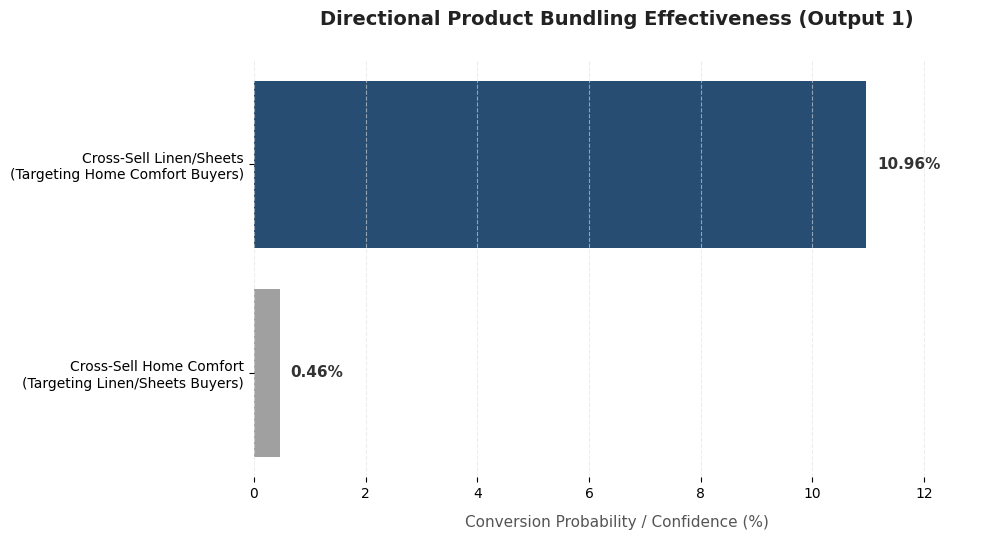

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

promo_strategies = [
    'Cross-Sell Linen/Sheets\n(Targeting Home Comfort Buyers)',
    'Cross-Sell Home Comfort\n(Targeting Linen/Sheets Buyers)'
]
confidence_metrics = [10.96, 0.46]

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.despine(left=True, bottom=True)

brand_palette = ['#1A4D80', '#A0A0A0']

barplot = sns.barplot(
    x=confidence_metrics,
    y=promo_strategies,
    palette=brand_palette,
    ax=ax
)

for bar in barplot.patches:
    val = bar.get_width()
    ax.text(
        val + 0.2,
        bar.get_y() + bar.get_height()/2,
        f'{val:.2f}%',
        va='center',
        ha='left',
        fontweight='bold',
        color='#333333',
        fontsize=11
    )

ax.set_title('Directional Product Bundling Effectiveness (Output 1)', fontsize=14, pad=25, fontweight='bold', color='#222222')
ax.set_xlabel('Conversion Probability / Confidence (%)', fontsize=11, labelpad=10, color='#555555')
ax.set_xlim(0, 13)
ax.xaxis.grid(True, linestyle='--', alpha=0.6, color='#E0E0E0')
ax.yaxis.grid(False)

plt.tight_layout()
plt.show()

Customer Lifetime Value


In [6]:
df_rfm_master = pd.merge(df_final, df_customers[['customer_id', 'customer_unique_id']], on='customer_id', how='inner')

latest_date = df_rfm_master['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm_df = df_rfm_master.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (latest_date - x.max()).days,
    'order_id': 'nunique',
    'price': 'sum'
}).reset_index()

rfm_df.columns = ['customer_id', 'recency', 'frequency', 'monetary']

rfm_df['r_score'] = pd.qcut(rfm_df['recency'], q=5, labels=[5, 4, 3, 2, 1])
rfm_df['f_score'] = pd.qcut(rfm_df['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm_df['m_score'] = pd.qcut(rfm_df['monetary'], q=5, labels=[1, 2, 3, 4, 5])

rfm_df['rfm_segment'] = (
    rfm_df['r_score'].astype(str) +
    rfm_df['f_score'].astype(str) +
    rfm_df['m_score'].astype(str)
)

rfm_df.head()

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,4,1,4,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,4,1,1,411
2,0000f46a3911fa3c0805444483337064,537,1,69.00,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00,2,1,5,215


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

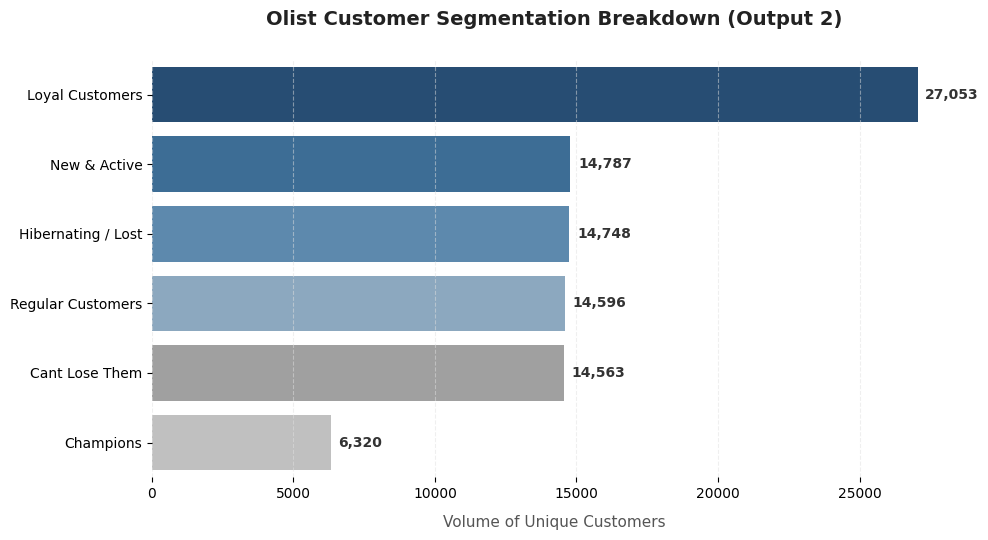

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [7]:
def assign_segment_label(row):
    r = int(row['r_score'])
    f = int(row['f_score'])
    m = int(row['m_score'])

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New & Active'
    elif r <= 2 and f >= 4:
        return 'Cant Lose Them'
    elif r <= 2 and f <= 2:
        return 'Hibernating / Lost'
    else:
        return 'Regular Customers'

rfm_df['segment_name'] = rfm_df.apply(assign_segment_label, axis=1)

segment_counts = rfm_df['segment_name'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Total Customers']

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.despine(left=True, bottom=True)

palette_theme = ['#1A4D80', '#2E6FA4', '#508BBA', '#84A9C7', '#A0A0A0', '#C0C0C0']

barplot = sns.barplot(
    x='Total Customers',
    y='Segment',
    data=segment_counts,
    palette=palette_theme,
    ax=ax
)

for bar in barplot.patches:
    width_val = bar.get_width()
    ax.text(
        width_val + (segment_counts['Total Customers'].max() * 0.01),
        bar.get_y() + bar.get_height()/2,
        f'{int(width_val):,}',
        va='center',
        ha='left',
        fontweight='bold',
        color='#333333'
    )

ax.set_title('Olist Customer Segmentation Breakdown (Output 2)', fontsize=14, pad=25, fontweight='bold', color='#222222')
ax.set_xlabel('Volume of Unique Customers', fontsize=11, labelpad=10, color='#555555')
ax.set_ylabel('')
ax.xaxis.grid(True, linestyle='--', alpha=0.5, color='#E0E0E0')

plt.tight_layout()
plt.show()

Final Output

In [8]:
premium_segments = ['Champions', 'Loyal Customers']
target_rfm = rfm_df[rfm_df['segment_name'].isin(premium_segments)]

target_orders = df_rfm_master[df_rfm_master['product_category'].isin(['home_confort', 'bed_bath_table'])]

marketing_target_list = pd.merge(
    target_orders[['customer_unique_id', 'product_id', 'product_category']],
    target_rfm[['customer_id', 'segment_name']],
    left_on='customer_unique_id',
    right_on='customer_id',
    how='inner'
).drop(columns=['customer_id'])

marketing_target_list.head()

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,customer_unique_id,product_id,product_category,segment_name
0,7ed0ea20347f67fe61d1c99fdf8556ae,99a4788cb24856965c36a24e339b6058,bed_bath_table,Loyal Customers
1,860fc00d3154ce2346c43ebe47b9b6ce,553e0e7590d3116a072507a3635d2877,bed_bath_table,Loyal Customers
2,cd6ab472aeca00c899a173ffea882881,84f456958365164420cfc80fbe4c7fab,bed_bath_table,Loyal Customers
3,cd6ab472aeca00c899a173ffea882881,84f456958365164420cfc80fbe4c7fab,bed_bath_table,Loyal Customers
4,8a44fe7a0a9fa910c26bdf99933e36aa,02ed3b595447e948efc3eac897e4df0e,bed_bath_table,Loyal Customers


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

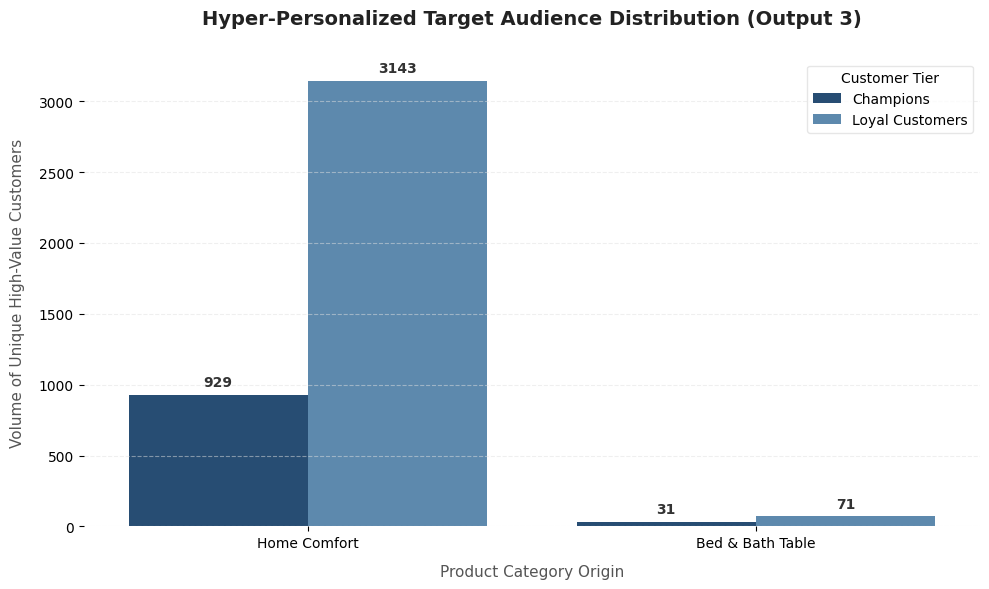

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

viz_payload = (
    marketing_target_list.groupby(['product_category', 'segment_name'])
    .size()
    .reset_index(name='Total Targets')
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.despine(left=True, bottom=True)

custom_colors = ['#1A4D80', '#508BBA']

barplot = sns.barplot(
    x='product_category',
    y='Total Targets',
    hue='segment_name',
    data=viz_payload,
    palette=custom_colors,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        fontweight='bold',
        color='#333333',
        label_type='edge',
        padding=4
    )

ax.set_title('Hyper-Personalized Target Audience Distribution (Output 3)', fontsize=14, pad=25, fontweight='bold', color='#222222')
ax.set_xlabel('Product Category Origin', fontsize=11, labelpad=10, color='#555555')
ax.set_ylabel('Volume of Unique High-Value Customers', fontsize=11, labelpad=10, color='#555555')
ax.set_xticklabels(['Home Comfort', 'Bed & Bath Table'])

ax.legend(title='Customer Tier', frameon=True, facecolor='#ffffff', edgecolor='#E0E0E0')
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#E0E0E0')
ax.xaxis.grid(False)

plt.tight_layout()
plt.show()